In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import label_binarize
from google.colab import drive
drive.mount('/content/drive')

CLASS_NAMES = ['Normal', 'Bacterial', 'Viral']

Mounted at /content/drive


In [2]:
df_results = pd.read_csv('/content/drive/MyDrive/resnet101_results.csv')
print("===== ResNet101 – Per Run Results =====")
print(df_results.to_string(index=False))

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
summary = pd.DataFrame({
    "Mean" : df_results[metrics].mean(),
    "Std"  : df_results[metrics].std(),
})
print("\n===== AVERAGE PERFORMANCE =====")
print(summary.round(4).to_string())

===== ResNet101 – Per Run Results =====
 Run  Accuracy  Precision   Recall  F1 Score
   1  0.828498   0.814658 0.828924  0.820670
   2  0.837031   0.829642 0.824161  0.824524

===== AVERAGE PERFORMANCE =====
             Mean     Std
Accuracy   0.8328  0.0060
Precision  0.8222  0.0106
Recall     0.8265  0.0034
F1 Score   0.8226  0.0027


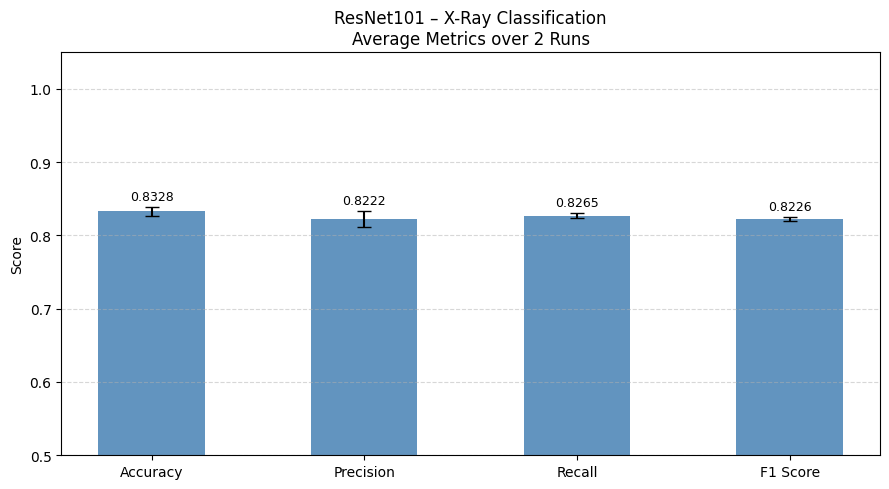

In [3]:
avg = df_results[metrics].mean()
std = df_results[metrics].std()

x     = np.arange(len(metrics))
width = 0.5

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(x, avg, width, yerr=std, color='steelblue', capsize=5, alpha=0.85)
ax.set_ylabel('Score')
ax.set_title('ResNet101 – X-Ray Classification\nAverage Metrics over 2 Runs')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.05)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

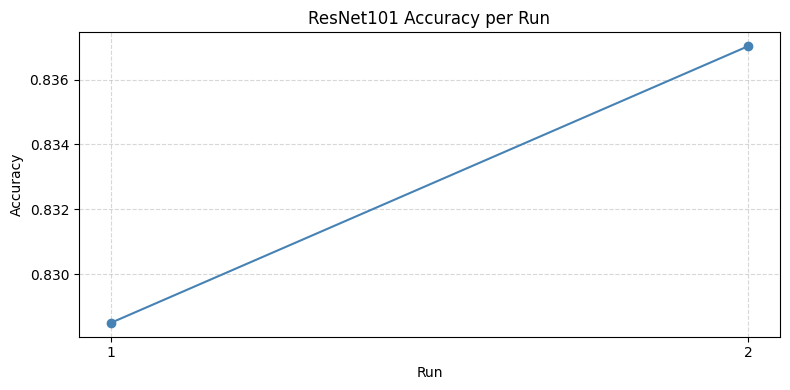

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(df_results["Run"], df_results["Accuracy"], 'o-', color='steelblue')
plt.xlabel('Run'); plt.ylabel('Accuracy')
plt.title('ResNet101 Accuracy per Run')
plt.xticks(df_results["Run"])
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [5]:
# Using Run 2 predictions for CM and ROC
y_pred_last  = np.load('/content/drive/MyDrive/resnet101_preds_run2.npy')
y_test_last  = np.load('/content/drive/MyDrive/resnet101_true_run2.npy')
y_probs_last = np.load('/content/drive/MyDrive/resnet101_probs_run2.npy')

print("Predictions loaded successfully ✓")
print(f"Test samples: {len(y_test_last)}")

Predictions loaded successfully ✓
Test samples: 1172


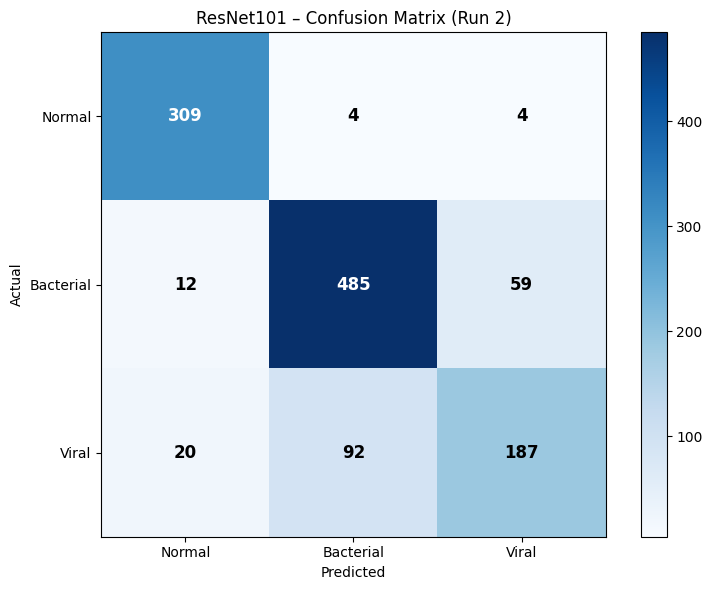

In [6]:
cm  = confusion_matrix(y_test_last, y_pred_last)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontsize=12, fontweight='bold')
ax.set_title('ResNet101 – Confusion Matrix (Run 2)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

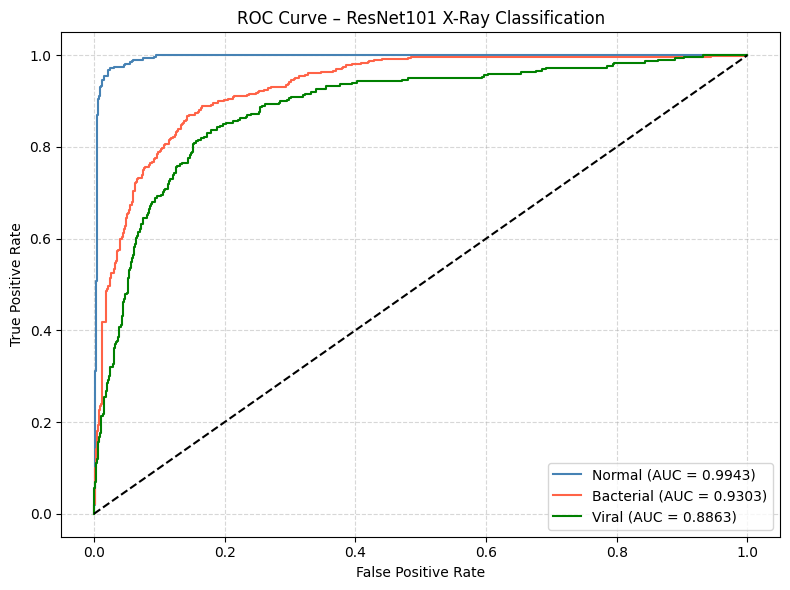

In [7]:
y_true_bin = label_binarize(y_test_last, classes=[0, 1, 2])
colors     = ['steelblue', 'tomato', 'green']

plt.figure(figsize=(8, 6))
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_last[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color,
             label=f'{cls_name} (AUC = {roc_auc:.4f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – ResNet101 X-Ray Classification')
plt.legend(); plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [8]:
print("===== ResNet101 – Classification Report (Run 2) =====")
print(classification_report(y_test_last, y_pred_last,
                             target_names=CLASS_NAMES))

===== ResNet101 – Classification Report (Run 2) =====
              precision    recall  f1-score   support

      Normal       0.91      0.97      0.94       317
   Bacterial       0.83      0.87      0.85       556
       Viral       0.75      0.63      0.68       299

    accuracy                           0.84      1172
   macro avg       0.83      0.82      0.82      1172
weighted avg       0.83      0.84      0.83      1172

